### Lecture 16

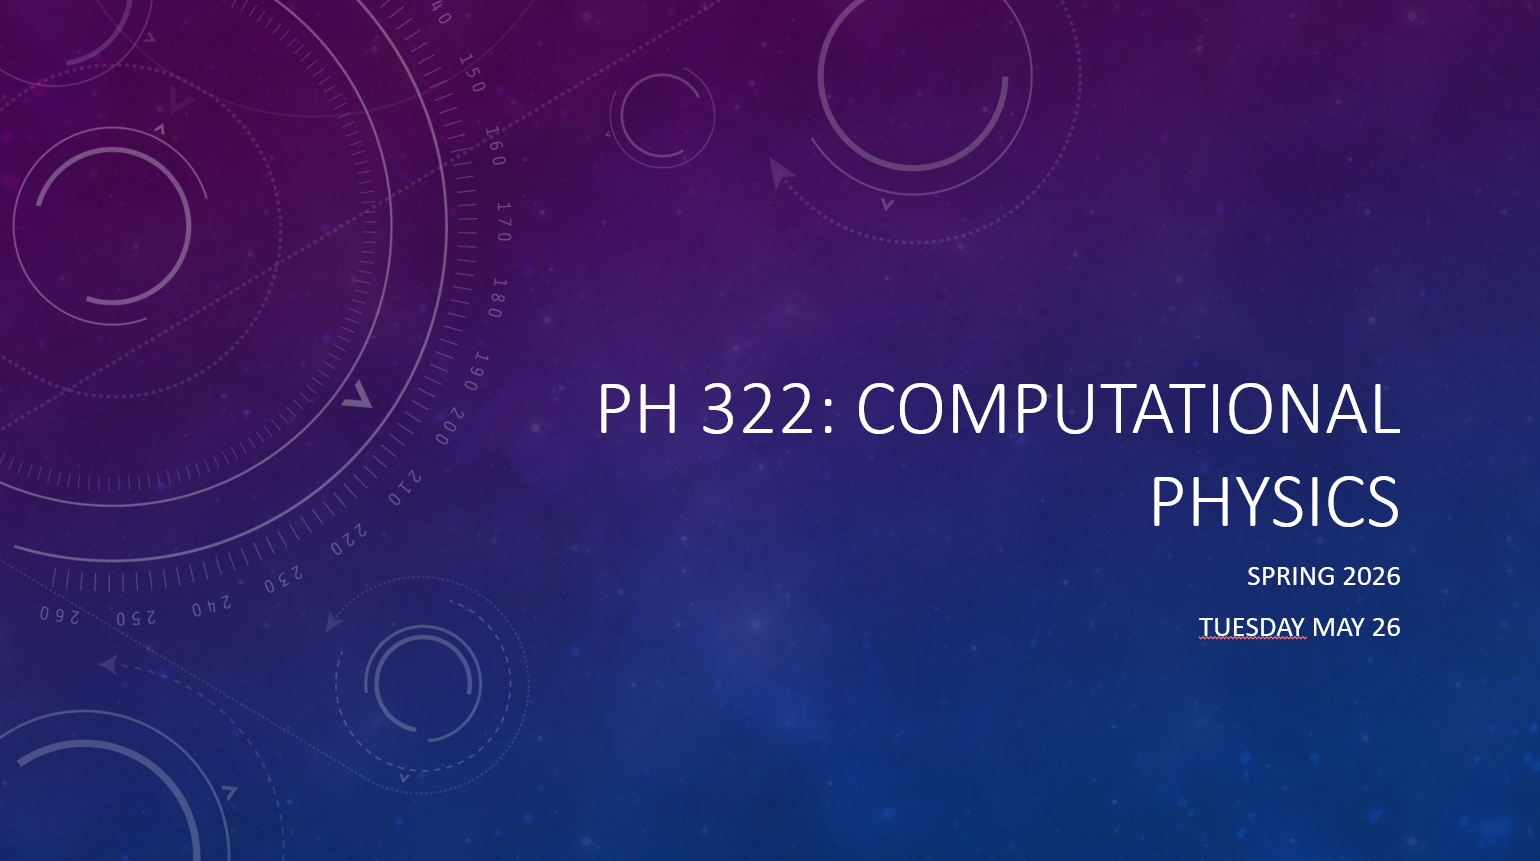

In [2]:
from IPython.display import Image, display
display(Image("G:\\My Drive\\Classes\\Ph322\\2026\\Lectures\\Figures\\header_lecture16.png"))

* HW 8 due tonight.
* Let me know if you wish to present your student project next week.


**Last Class**

* Solving the diffusion equation.
* Forward-Time Centered-Space (FTCS) method for PDEs.
* Numerical stability using the FTCS method.


**Today's Class**

* Chapter 7
    * Fourier Series
    * Fourier Transform
    * Discrete Fourier Transform (DFT)
    * Inverse DFT
    * DFT of a sampled function
    * DFT of numerical data


# Fourier Transforms

Fourier transforms are incredibly important in computational physics and data analysis. The use of a Fourier transform (FT) allows us to break down a periodic waveform or signal into its component parts, which we can use for various purposes including smoothing, filtering, and investigation into periodicities and phases. 

We will first review Fourier series, then learn the discrete Fourier transform algorithm, then the fast Fourier transform. It comes as no surpise that since the use of Fourier transforms is so common the ```numpy``` module has functions to perform FTs. We will use these to verify the FT functions we write ourselves, then later use them in more advanced applications.

But first let's review Fourier series.

### Fourier series

A Fourier series, similar to a Taylor's series, is a way of representing a function as a sum of an infinite number of terms. Unlike the Taylor's series where each term in the series is a derivative of the function, in a Fourier series the terms are sine and cosine functions. There are two classes of functions where the Taylor series is not well suited, periodic functions, and functions with discontinuities which often exist with functions comprised of numerical data.

A Fourier series exists for a function that is continuous over a bounded interval, say from $0\le x< L$. The terms in the Fourier series consist of sine and cosines functions that are weighted by factors that depend on the function we are approximating. When we sum the terms we get a function that approximates the original function over the specified interval. This function repeats outside the specified interval and approximates the original function outside the defined interval if the original function is periodic as well.

### cosine series

We can use just cosines, just sines, or a combination of sines and cosine functions for each term.

If we use just cosines, then the series is called a *cosine series*. The cosine function is symmetric over one cycle from $0$ to $2\pi$:


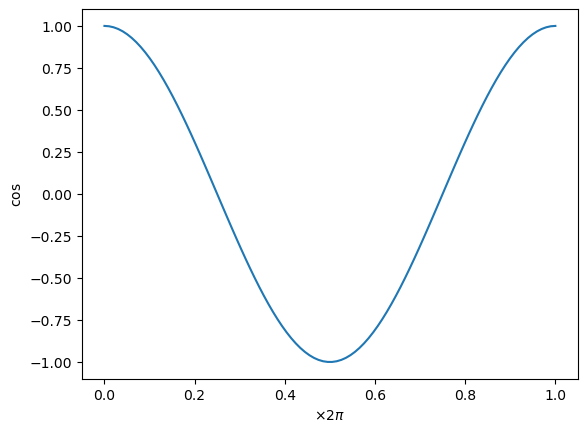

In [1]:
#plot the cosine function from 0 to 2pi

from numpy import linspace, cos
from math import pi
import matplotlib.pyplot as plt

# cosine term 
def f(x):
    return cos(x)

x = linspace(0,2*pi,100)
y = f(x)

plt.plot(x/(2*pi),y)
plt.xlabel(r"$\times2\pi$")
plt.ylabel(r"$\cos$")
plt.show()


Because the cosine function is symmetric the cosine series is good to approximate functions that are symmetric across the interval. 

Using the cosine series we can write an arbitrary function $f(x)$ over an interval $L$ as a sum of $k$ cosine functions multiplied by coefficients $\alpha_k$: 

$$
f(x)=\sum_{k=0}^{\infty}\alpha_{k}\cos(\frac{2\pi kx}{L}).
$$

Though the cosines themselves will be the same for each function $f(x)$, the coefficients $\alpha_k$ are determined by the function itself. The first three terms are:

$$
f(x) = \alpha_{0}\cos(0) + \alpha_{1}\cos(\frac{2\pi x}{L}) + \alpha_{2}\cos(\frac{4\pi x}{L}) + \ldots
$$

Let's go ahead and plot the first three terms of the cosine series for different sets of coefficients. In this first example, we simply set all coefficients to 1 and set the interval length $L$ to $10\pi$.

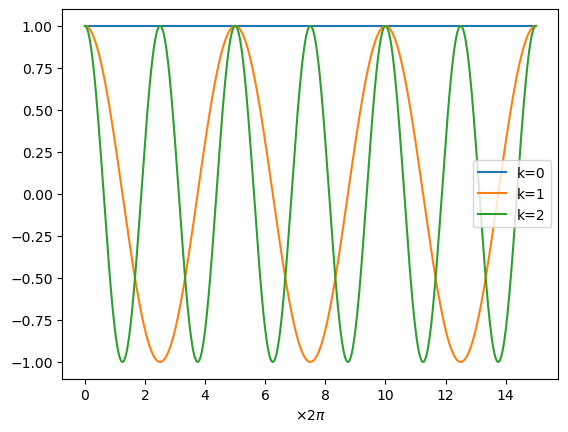

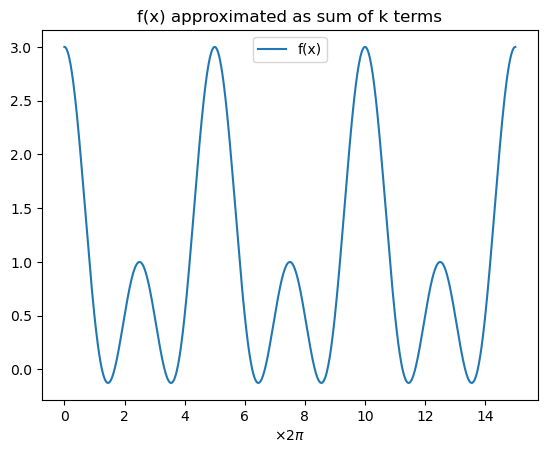

In [7]:
# plot the cosine series with all coefficients = 1

import matplotlib.pyplot as plt
import numpy as np

# cosine term 
def f_cos(k,x):
    return np.cos(2*np.pi*k*x/L)

# define the interval to be from L=0, 10pi
L = 5*(2*np.pi)

# hold x values for an interval of 3L
x = np.linspace(0,3*L,1000)

# hold y values of cosine terms
fx = np.zeros([len(x)],float)

# number of terms to include
N=3

# plot each cosine term and sum the n terms
for k in range(N):
    plt.plot(x/(2*np.pi),f_cos(k,x), label="k="+str(k))
    fx += f_cos(k,x)
plt.xlabel(r"$\times2\pi$")
plt.legend()
plt.show()

# plot the sum of the cosine terms
plt.plot(x/(2*np.pi),fx, label="f(x)")
plt.xlabel(r"$\times2\pi$")
plt.legend()
plt.title("f(x) approximated as sum of k terms")
plt.show()

When we plot the approximation to the function $f(x)$ calculated from the sum of terms, we see that the function repeats over the interval from $0$ to $L$. As we increase the number of terms in the sum, we get a better approximation to the true function. In this first example all the coefficients are equal to one. 

Let's try a more complicated set of coefficients defined by:

$$
\alpha_k =
\begin{cases}
\frac{L^2}{3} & k=0 \\
\frac{4L^2(-1)^k}{k^2\pi^2} & k=1,2,3,\ldots \\
\end{cases}
$$


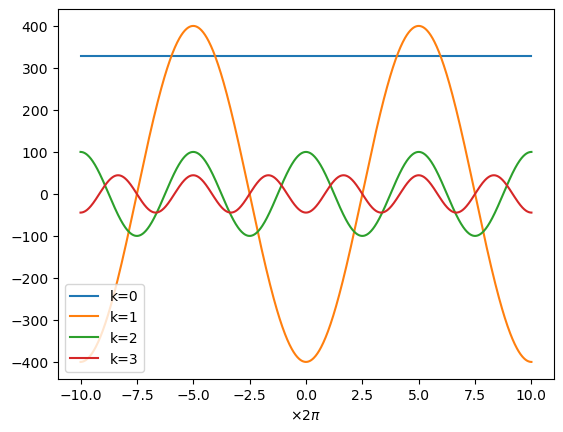

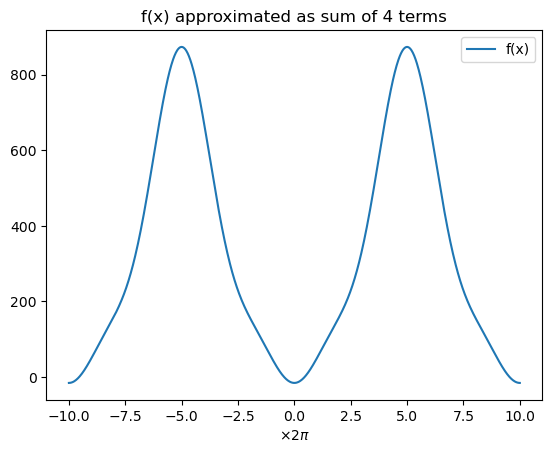

In [4]:
# plot the cosine series with set of coefficients defined above

import matplotlib.pyplot as plt
import numpy as np

# cosine term 
def f_cos(k,x,L):
    if k==0:
        alpha = L**2/3
    else:
        alpha = (4*L**2*(-1)**k)/(k*np.pi)**2
    return alpha*np.cos(np.pi*k*x/L)

# define the interval to be from L=0, 10pi
L = 5*(2*np.pi)
x = np.linspace(-2*L,2*L,1000)


fx = np.zeros([len(x)],float)
# calculate and plot the first N terms of the cosine series

# number of terms to include
N=4
for k in range(N):
    plt.plot(x/(2*np.pi),f_cos(k,x,L), label="k="+str(k))
    fx += f_cos(k,x,L)
plt.xlabel(r"$\times2\pi$")
plt.legend()
plt.show()

# plot the sum of the cosine terms
plt.plot(x/(2*np.pi),fx, label="f(x)")
plt.xlabel(r"$\times2\pi$")
plt.title(f"f(x) approximated as sum of {N} terms")
plt.legend()
plt.show()

You can play around with the code and add more and more terms. As you do you should see $f(x)$ become more defined. In fact it should look like the function $f(x)=x^2$, which is the function I used to calculate the coefficients $\alpha_k$. So the point is, we can build up a function using a bunch of cosine terms.

 

## sine series

Likewise, we can also define the Fourier series using sine functions in place of cosines. 
$$
f(x)=\sum_{k=1}^{\infty}\alpha_{k}\sin(\frac{2\pi kx}{L})
$$

$$
f(x) =  \alpha_{1}\sin(\frac{2\pi x}{L}) + \alpha_{2}\sin(\frac{4\pi x}{L}) + \ldots
$$

Note here the summation begins at $k=1$ because the sine of zero is zero. 

Because the sine function is antisymmetric about the midpoint of the interval as the plot below shows, the sine series can approximate antisymmetric functions well. An antisymmetric function is one where $f(x)=-f(-x)$.  


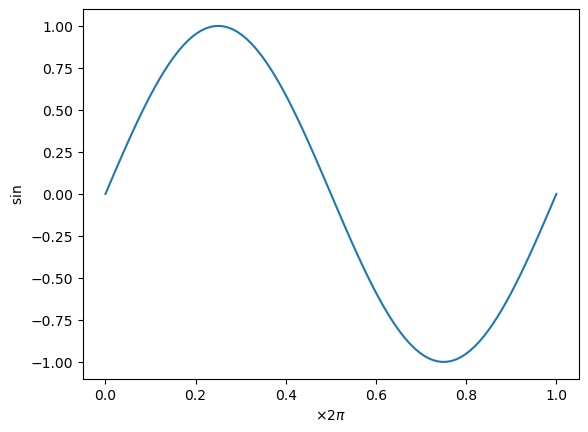

In [3]:
#plot the sine function from 0 to 2pi

import matplotlib.pyplot as plt
import numpy as np

# sine term 
def f(x):
    return np.sin(x)

# calculate sine over 0,2pi
x = np.linspace(0,2*np.pi,100)
y = f(x)

plt.plot(x/(2*np.pi),y)
plt.xlabel(r"$\times2\pi$")
plt.ylabel(r"$\sin$")
plt.show()

 Again we can build up functions using the sine series. Here we plot the first N terms of the sine series and its sum, assuming the coefficients are all one.

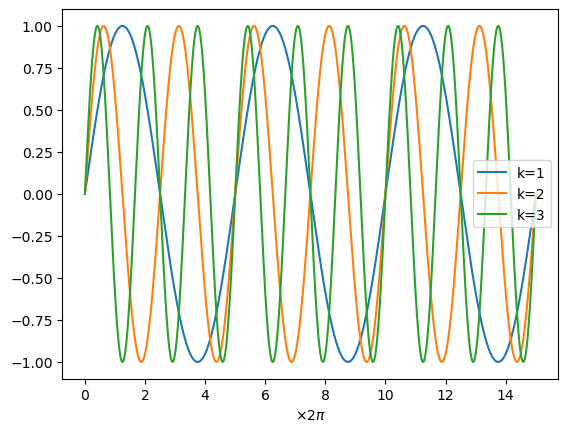

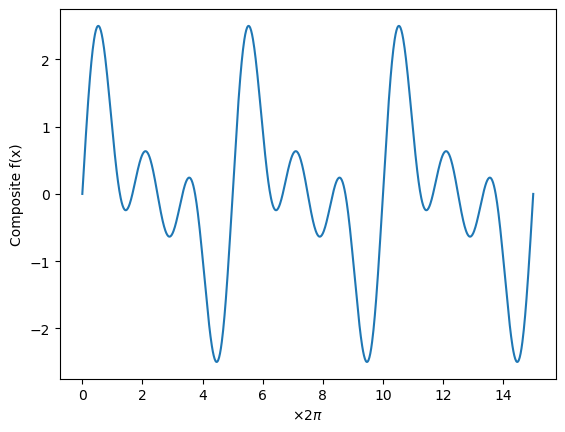

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def f_sin(k,x,L):
    return np.sin(2*np.pi*k*x/L)

# set the number of terms in series
N = 3

# define the interval to be from L=0, 10pi
L = 5*(2*np.pi)
x = np.linspace(0,3*L,1000)

# plot each term in sine series
for k in range(1,N+1):
    plt.plot(x/(2*np.pi),f_sin(k,x,L), label="k="+str(k))

plt.xlabel(r"$\times2\pi$")
plt.legend()
plt.show()

# h will hold the composite sum
h=0

# calculate the composite sum using N terms
for k in range(1,N+1):
    h+=f_sin(k,x,L)

# plot the composite sum
plt.plot(x/(2*np.pi),h)
plt.xlabel(r"$\times2\pi$")
plt.ylabel("Composite f(x)")
plt.show()

## General sin/cos series

A general Fourier series is created using both sine and cosine terms in the series

$$
f(x)=\sum_{k=0}^{\infty}\alpha_{k}\cos(\frac{2\pi kx}{L}) + \sum_{k=1}^{\infty}\beta_{k}\sin(\frac{2\pi kx}{L})
$$

Again we can plot the first few terms of this series assuming all coefficients are one and the composite function:

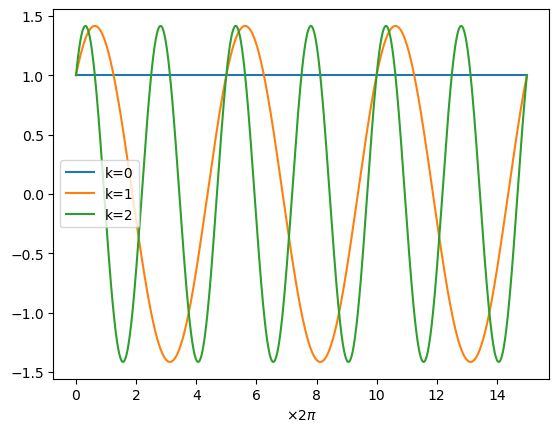

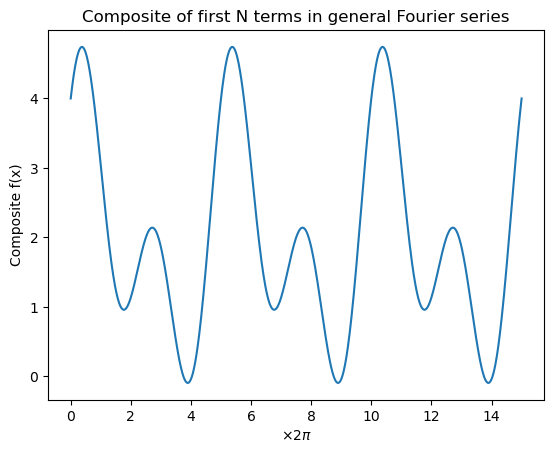

In [9]:
## plot the first few terms of the general form of the Fourier series
import numpy as np
import matplotlib.pyplot as plt


# sum of cosine and sine functions
def f_general(k,x,L):
    return np.cos(2*np.pi*k*x/L) + np.sin(2*np.pi*k*x/L)

# set the number of terms
N=3

# define the interval to be from L=0, 10pi
L = 5*(2*np.pi)
x = np.linspace(0,3*L,1000)

# plot the first N terms of the general Fourier series
for k in range(N):
    plt.plot(x/(2*np.pi),f_general(k,x,L), label="k="+str(k))
    
plt.xlabel(r"$\times2\pi$")
plt.legend()
plt.show()

# initialize variable that will hold composite
y=f_general(0,x,L)

# calculate composite of first N terms in general Fourier series
for k in range(N):
    y+=f_general(k,x,L)
    
# plot composite of first N terms in general Fourier series
plt.plot(x/(2*np.pi),y)
plt.xlabel(r"$\times2\pi$")
plt.ylabel("Composite f(x)")
plt.title("Composite of first N terms in general Fourier series")
plt.show()
    


We can write the general form of the Fourier series in terms of exponential functions using the Euler identities for $\cos\theta$ and $\sin\theta$:

$$
\cos{\theta} = \frac{e^{-i\theta}+e^{i\theta}}{2},
$$

$$
\sin{\theta} = \frac{e^{i\theta} -e^{-i\theta}}{2i},
$$

where *i* is the imaginary number.

Here I plot the identities just to show they are indeed the same:

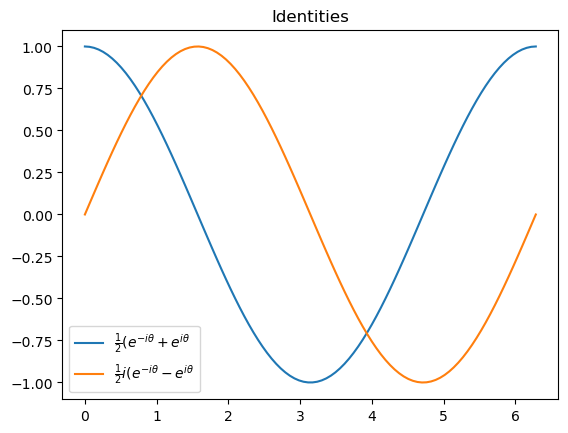

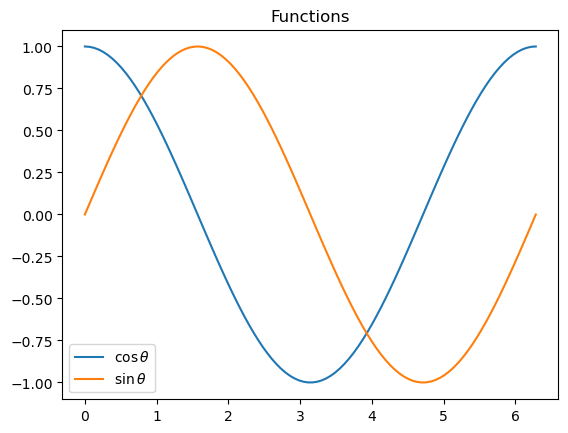

In [32]:
#plot the cosine and sine identities using complex math functions

import numpy as np

def cos_identity(theta):
    return 0.5*(np.exp((-1j)*theta)+np.exp((1j)*theta))

def sin_identity(theta):
    return 0.5*1j*(np.exp((-1j)*theta)-np.exp((1j)*theta))

theta = np.linspace(0,2*np.pi, 100)

# calculate the sin,cos identities
cos_i = cos_identity(theta)
sin_i = sin_identity(theta)

#calculate the sin, cos functions
cos_f = np.cos(theta)
sin_f = np.sin(theta)


#plot the identities
plt.plot(theta,cos_i, label=r"$\frac{1}{2}(e^{-i\theta}+e^{i\theta}$")
plt.plot(theta,sin_i, label=r"$\frac{1}{2}i(e^{-i\theta} -e^{i\theta}$")
plt.legend()
plt.title("Identities")
plt.show()

plt.plot(theta,cos_f, label=r"$\cos{\theta}$")
plt.plot(theta,sin_f, label=r"$\sin{\theta}$")
plt.legend()
plt.title("Functions")
plt.show()

Using these identities we can write the general form of the Fourier series in a compact form as:

$$
f(x) = \sum_{k=-\infty}^{\infty}\gamma_k\exp{\left(i\frac{2\pi kx}{L}\right)}
$$

where the coefficients $\gamma_k$ are given by:

$$
\gamma_k = 
\begin{cases}
\frac{1}{2}(\alpha_{|k|}+i\beta_{|k|}) &  k<0 \\
\alpha_0 & k=0 \\
\frac{1}{2}(\alpha_{k}-i\beta_{k}) &  k>0 \\
\end{cases}
$$


Most of the work in calculating the Fourier series is in calculating the coefficients. We see the coefficients are complex, with the real parts of the coefficients determined from the amplitudes of the cosine terms, and the imaginary parts from the sine  terms. The real part also controls the amplitude of the exponential terms when the Fourier series is written as a complex series, and the imaginary part determines the phase of each term.   


**Finding the coefficients**

The standard way to calculate each coefficient of the Fourier series for some function is to take the inner product of the function $f(x)$ with each term in the Fourier series, where the inner product is:

$$
<f(x),g(x)> = \int^{b}_{a}f(x)g(x) dx
$$

If we think about the $\cos$ and $\sin$ terms in the Fourier series as being basis functions in a vector space, this means we are essentially projecting the function $f(x)$ onto each basis function, exactly as we would when we take the dot product of any two vectors. The dot product is a measure of how much of the function "is present" in the basis function.


To get a feel for this let's calculate the coefficients of the Fourier series using the function $f(x)=x^2$ over the interval $(-\pi, \pi)$. To simplify, we will only use cosine terms in the Fourier series.

The coefficient of the $n$-th harmonic is given by:

$$
a_n = \frac{1}{\pi}\int^{\pi}_{-\pi}f(x)\cos \frac{2\pi nx}{L} dx
$$

So the coefficient of the first harmonic is

$$
a_1 = \frac{1}{\pi}\int^{\pi}_{-\pi}f(x)\cos \frac{2\pi x}{L} dx ;
$$

the coefficient for the second harmonic is:

$$
a_2 = \frac{1}{\pi}\int^{\pi}_{-\pi}f(x)\cos \frac{4\pi x}{L} dx, 
$$

etc.

Once we have the coefficient for harmonic $n$, we can construct the Fourier term for that harmonic and approximate our function $x^2$ by summing the terms.

This is what the following program does. 

The user can specify how many harmonics to plot. The top subplot shows the integrands of each harmonic, $x^2 \cos \frac{2\pi nx}{L}$. 

The program then integrates the integrand over the interval $(-\pi, \pi)$, and calculates the coefficient $a_n$. The Fourier term for harmonic $n$ is then constructed using $a_n \cos \frac{2\pi nx}{L}$, and plotted in the middle subplot. 

Finally, the Fourier terms for all harmonics are summed and plotted in the bottom subplot. This curve should start to resemble $x^2$ as we increase the number of harmonics.

I use the ```quad()``` function from ```scipy.integrate``` to perform the integration using Gaussian quadrature.

Let's give it a go.

Enter the number of harmonics to plot:  4


Fourier Coefficient (n=1): -3.9999999999999982
Fourier Coefficient (n=2): 1.000000000000001
Fourier Coefficient (n=3): -0.44444444444444475
Fourier Coefficient (n=4): 0.25000000000000006


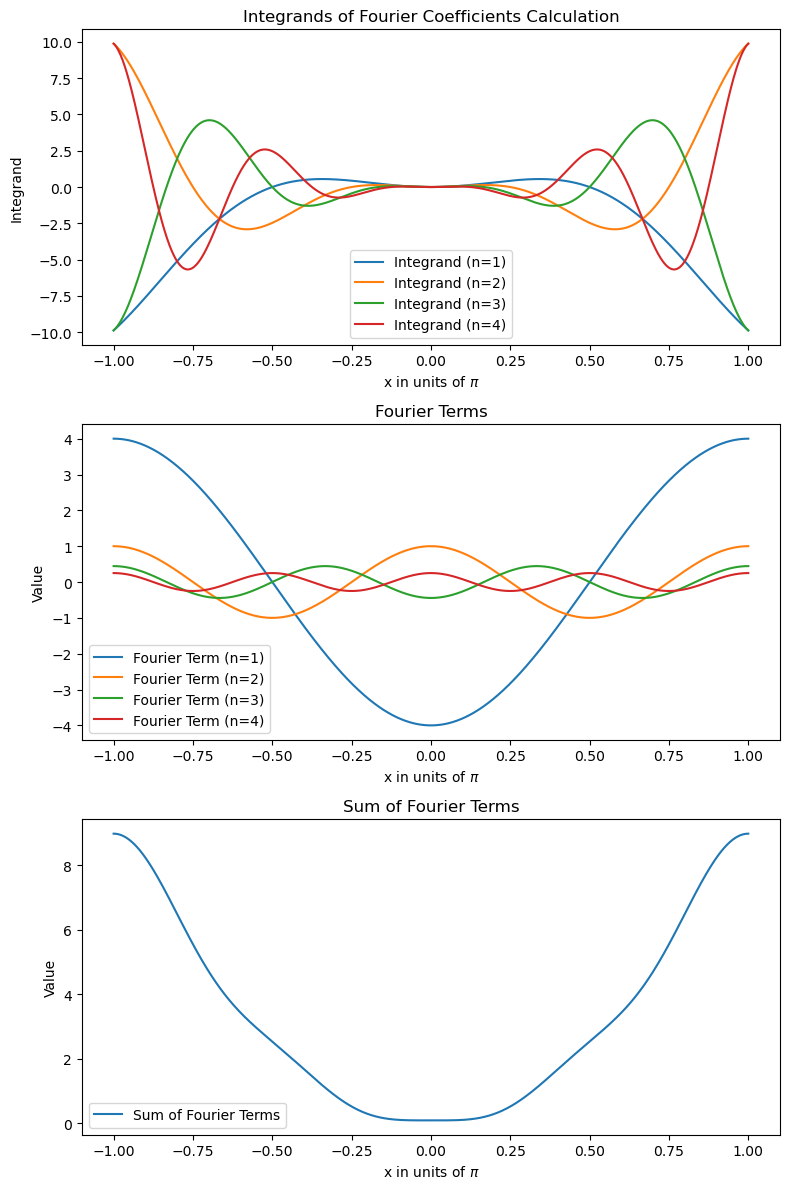

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Define the function f(x)
def f(x):
    return x**2

# Define the integrand for the Fourier coefficients
def integrand(x, n, L):
    return f(x) * np.cos(2*np.pi*n * x/L)

# Define the Fourier harmonic term
def fourier_term(x, n, a_n, L):
    return a_n  * np.cos(2*np.pi*n * x/L)

# Define the interval and number of points
start = -np.pi
end = np.pi
L = end - start
num_points = 1000

# Create an array of points within the interval
x = np.linspace(start, end, num=num_points)

# Prompt the user to enter the number of harmonics
num_harmonics = int(input("Enter the number of harmonics to plot: "))

# Create subplots for integrands, Fourier terms, and sum of terms
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 12))

# Plot the integrands
for n in range(1, num_harmonics + 1):
    # Compute the integrand values
    integrand_values = integrand(x, n, L)
    
    # Plot the integrand
    ax1.plot(x/np.pi, integrand_values, label=f'Integrand (n={n})')

# Set the plot title and labels for integrands
ax1.set_title('Integrands of Fourier Coefficients Calculation')
ax1.set_xlabel(r'x in units of $\pi$')
ax1.set_ylabel('Integrand')
ax1.legend()

# Initialize the sum of Fourier terms
sum_fourier_terms = 0

# add in the constant term
sum_fourier_terms = (1/3)*(np.pi)**2

# Plot the Fourier terms
for n in range(1, num_harmonics + 1):
    # Compute the Fourier coefficient
    fourier_coefficient, _ = quad(integrand, start, end, args=(n,L))
    
    # divide the coefficient by pi
    fourier_coefficient *= 1/np.pi
    
    print(f"Fourier Coefficient (n={n}):", fourier_coefficient)
    
    # Compute the Fourier term
    fourier_term_values = fourier_term(x, n, fourier_coefficient, L)
    
    # Plot the Fourier term
    ax2.plot(x/np.pi, fourier_term_values, label=f'Fourier Term (n={n})')
    
    # Add the Fourier term to the sum
    sum_fourier_terms += fourier_term_values

# Set the plot title and labels for Fourier terms
ax2.set_title('Fourier Terms')
ax2.set_xlabel(r'x in units of $\pi$')
ax2.set_ylabel('Value')
ax2.legend()

# Plot the sum of Fourier terms
ax3.plot(x/np.pi, sum_fourier_terms, label='Sum of Fourier Terms')

# Set the plot title and labels for the sum of terms
ax3.set_title('Sum of Fourier Terms')
ax3.set_xlabel(r'x in units of $\pi$')
ax3.set_ylabel('Value')
ax3.legend()

# Adjust spacing between subplots
plt.tight_layout()

# Display the plots
plt.show()


Following the same logic, we can calculate the coefficients for our general Fourier series above with the integral: 

$$
\gamma_k = \frac{1}{L} \int_0^L f(x) \exp{\left(-i\frac{2\pi kx}{L}\right)}dx
$$

Here we are projecting $f(x)$ onto the set of complex exponential functions in order to derive an equation for the $\gamma_k$ coefficients.



This then tells us how to calculate the coefficient or the weight of each term in our Fourier series summation above. Let me rewrite that equation here for convenience:

$$
f(x) = \sum_{k=-\infty}^{\infty}\gamma_k\exp{\left(i\frac{2\pi kx}{L}\right)}.
$$

So this is the analytical Fourier transform that can be used to find the Fourier coeffiecients for some function $f(x)$ for which we have an analytical expression.  But often times we don't have an analytical form of $f(x)$; we instead may have a data set of discrete measurements. In this case we need a numerical method to find the coefficients. 

Enter the discrete Fourier transform. 

## Derivation of the Discrete Fourier Transform 

The discrete fourier transform is one of the most common methods to do numerical Fourier analysis. It is a method that calculates the coefficients of the Fourier series by sampling the function, or as is often the case, a set of discrete measurements we are processing.

To derive the DFT we start by noticing that to calculate the coefficient $\gamma_k$ we need to evaluate the integral:

$$
\int_0^L f(x) \exp{\left(-i\frac{2\pi kx}{L}\right)}dx
$$

Let's do this using the trapezoidal rule.

As a refresher the trapezoidal rule is:

$$
I(a,b) \sim h\left[\frac{1}{2}f(a) +  \frac{1}{2}f(b) + \sum_{k=1}^{N-1}f(a+kh)\right]
$$

In the above integral the integration interval is $L$, therefore if we use $N$ slices to sample the function, the slice width is $h=L/N$. 

With that we can write the trapezoidal rule for the integral as:

$$
I(0,L)  \sim \frac{L}{N} \left[\frac{1}{2}(f(0) \exp{\left(-i\frac{2\pi k(0)}{L}\right)}) +  \frac{1}{2}(f(L) \exp{\left(-i\frac{2\pi k(L)}{L}\right)}) + \sum_{n=1}^{N-1}f(x_n)\exp{\left(-i\frac{2\pi kx_n}{L}\right)}\right] 
$$

Since $\exp{\left(-i\frac{2\pi k(0)}{L}\right)}$ and $\exp{\left(-i\frac{2\pi k(L)}{L}\right)}$ equal 1:

$$
I(0,L)  \sim \frac{L}{N} \left[\frac{1}{2}f(0) +  \frac{1}{2}f(L) + \sum_{n=1}^{N-1}f(x_n)\exp{\left(-i\frac{2\pi kx_n}{L}\right)}\right], 
$$



where $x_n$ are the sampling points given by $x_n = \frac{n}{N}L$.

The notation here can get a little confusing. $k$ no longer refers to the $k$th integration slice, rather $k$ here is the index of the $k$th Fourier series term we're calculating. Remember, the above equation is for $\gamma_k$, the coefficient of the $k$th series term. $n$ now designates the $n$th integration slice in the trapezoidal rule.

We impose the condition of periodicity on $f(x)$, so $f(0)=f(L)$. This means effectively we are making our function, which may only be defined over $0$ to $L$, or our finite data set, continuous. 

If so then:

$$
\frac{1}{2}f(0) +  \frac{1}{2}f(L) = f(0).
$$

And since the coefficient on this $n=0$ term is 1 just like all other terms, and $x_n=0$, making $\exp{\left(-i\frac{2\pi kx_n}{L}\right)}=1$,  we can add this term into the summation but start the summation now at $n=0$.

This allows us to write the trapezoidal rule as:

$$
I(0,L)  \sim \frac{L}{N} \left[ \sum_{n=0}^{N-1}f(x_n)\exp{\left(-i\frac{2\pi kx_n}{L}\right)}\right] 
$$


And since $\gamma_k = \frac{1}{L}I(0,L)$ (from above),

$$
\gamma_k = \frac{1}{N}\left[ \sum_{n=0}^{N-1}f(x_n)\exp{\left(-i\frac{2\pi kx_n}{L}\right)}\right] 
$$

So this gives us an equation we can use to calculate the coefficients for a continuous function $f(x)$, by sampling the function at locations $x_n$.



More often when we are working with data or measurements we may have data that are sampled at equally spaced points $x_n$, e.g. CO$_2$ data measured monthly or a sound wave sampled at equal time intervals.

In this case we don't have a continuous function, rather a set of data that we can call $y_n$, where for $N$ samples, $n=0, \ldots, N-1$.

So:

$$
\gamma_k = \frac{1}{N}\left[ \sum_{n=0}^{N-1}y_n\exp{\left(-i\frac{2\pi kx_n}{L}\right)}\right] 
$$

and if the $N$ data are spaced evenly over the interval L, then $x_n= \frac{nL}{N}$ and:


$$
\boxed{\gamma_k = \frac{1}{N}\underbrace{\left[ \sum_{n=0}^{N-1}y_n\exp{\left(-i\frac{2\pi kn}{N}\right)}\right]}_{DFT}}
$$

Notice now the sampling locations $x_n$ and the interval $L$ no longer enter the equation. The summation is called the **discrete Fourier transform**. We can think of it as a way of calculating the coefficients or weights for each sinusoidal term in our Fourier series, or alternatively as a mapping of our function or sample from the time domain into the frequency domain. The coefficients $\gamma_k$ are complex and provide both the magnitude and phase of the $k$th harmonic or term in the series.

As a matter of notation we will refer to the members of the DFT as $c_k$, such that 

$$
c_k =  \sum_{n=0}^{N-1}y_n\exp{\left(-i\frac{2\pi kn}{N}\right)}
$$

and the Fourier coefficients are 

$$
\gamma_k = \frac{1}{N} c_k
$$

#### Coding the DFT

To compute the full set of $c_k$'s, we need to use a nested ```for``` loop. The outer loop will iterate over each $c_k$, and the inner loop will perform the sum from n=0, N-1 for each coefficient. 

The pseudocode for the DFT might look like:

* Define the number of sample points $N$ if we are sampling a function. Otherwise $N$ is determined by number of data points. 
* Sample the function at these points.
* Create an array to store the DFT coefficients. These will be complex. 
* Decide the max coefficient to calculate, $k_max$.
* Calculate each $c_k$ by looping from $k=0, k_max$.
    * Within this loop, loop from $n=0, N-1$, multiplying each sample $y_n$ by the exponential term and summing each term.



### Practice exercise - Discrete Fourier Transform of a continuous function

Write a program that calculates the DFT for the function $f(x) = x^2$ over $x=-1$ to $x=1$.  Sample the function using $N = 100$ points, and calculate $c_k$ for $k=0$ to $k=N-1$.

Make a plot of the DFT, i.e., plot $c_k$ vs. $k$.  

Notes:
* Use either the ```exp()``` function from ```numpy``` or from the ```cmath``` module to work with complex numbers.
* Remember in Python, the imaginary number $i$ is denoted by ```j```.
* Since the coefficients are complex, plot only the real components by using the ```abs()``` function.
* If you use an array to store the coefficients, initialize it for complex variables.


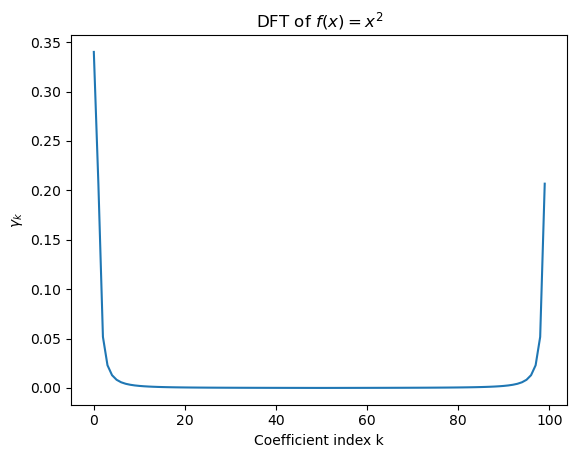

In [10]:
### Practice exercise - DFT of function f(x) = x^2


### Inverse DFT

When we perform a DFT we map the original sampled function (or data) to the frequency domain. We can also do the reverse and reconstruct the original sampled data from the DFT coefficients. This is called taking the **inverse discrete Fourier transform**, and is given by (see textbook for derivation):

$$
y_n = \sum_{k=0}^{N-1}\gamma_k\exp{\left(i\frac{2\pi kn}{N}\right)},
$$

where $y_n$ are the original sampled function or data, and $c_K$ are the DFT coefficients.    Note the sign of the exponential term has changed (this is the complex conjugate).

One interesting thing about the inverse DFT, it says that we can calculate or recover if you like, the nth sample by simply summing up the $k$ terms from $k=0, N-1$. That is to say, that if we calculate the first N coefficients (where N is the number of samples) of the Fourier series (or more precisely $c_k$), then we can completely recover the sampled data from those coefficients.  In essence this means that all the information in our data is stored in $c_k$. No information is lost. So we can easily go back and forth between $y_n$ and $c_k$ for $k$ up to N-1.

That also tells us that to completely represent the original data we only need to calculate $c_k$ up to $k=N-1$, not infinity. 

If we compare the inverse DFT with the general form of the Fourier series:

$$
f(x) = \sum_{k=-\infty}^{\infty}\gamma_k\exp{\left(i\frac{2\pi kx}{L}\right)}
$$

we some differences. First the general form is a summation from $-\infty$ to $\infty$ and the inverse DFT is just over the positive $k's$. This shows some limitations with the inverse DFT. The inverse DFT only gives us back the values at the sampled parts of the function, not the points in between which the above equation can do. In other words, the $c_k$ we calculate don't contain any information about the function in between the sampling points. 

Generally this is fine if the function is well-behaved between the sampling points. And as we mentioned, in many cases we only have the sampled data to begin with.

### Practice Exercise: Inverse DFT

Once you have your program above working to calculate the DFT of $f(x)=x^2$, take the inverse DFT of your coefficients to reproduce the original sample data. 

Plot your inverse DFT against the original sampled data.  

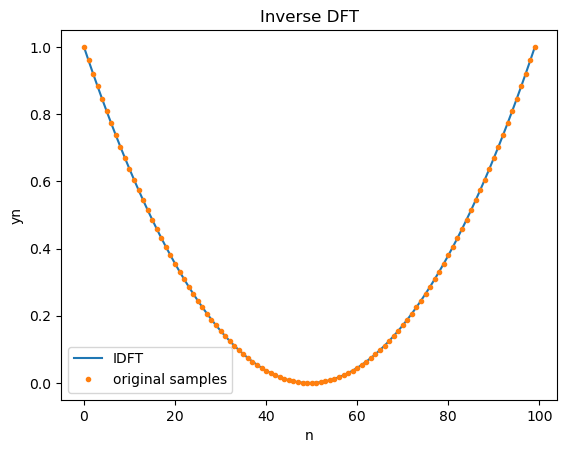

In [12]:
# practice exericse - calculate inverse DFT.  This cell uses info from previous cell.



### Application of the DFT to a time series of measurements

Next let's apply this and calculate the DFT for a time series of real data. In this case, we will work with a data set of monthly carbon dioxide (CO2) measurements taken from Mauna Loa. We used this data set earlier this term.  Note to run the following code you will need to download the file "monthly_in_situ_co2_mlo_2026.txt" and put in your working directory. 

First we will plot the data:

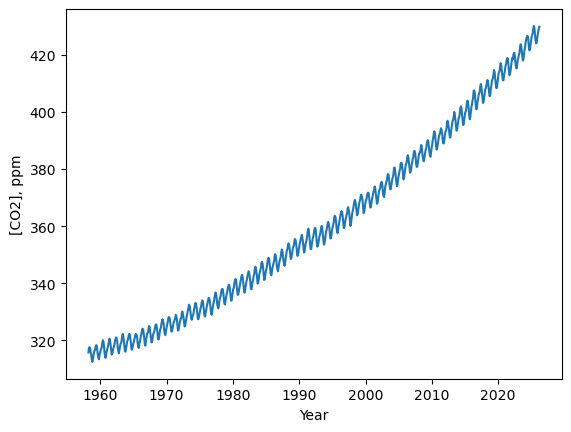

In [14]:
# Calculate DFTof Mauna Loa CO2 data

import numpy as np
from cmath import exp, pi
import matplotlib.pyplot as plt

# directory path to data file
path = "G:\\My Drive\\Classes\\Ph322\\Data files\\"
file = "monthly_in_situ_co2_mlo_2026.txt"

# load in the file "monthly_in_situ_co2_mlo.txt"
data = np.loadtxt(path+file)
#data = np.loadtxt(file)
# col 2 contains date in units of days
day = data[:,2]
# col 3 contains date in units of years
year = data[:,3]
# col 4 contains CO2 in units of ppb
co2 = data[:,4]

#plot CO2 vs year
plt.plot(year, co2, '-')
plt.xlabel("Year")
plt.ylabel("[CO2], ppm")
plt.show()

Again we see that the data has a seasonal cycle with a large upward trend.

Now let us calculate the DFT, that is calculate the coefficients $c_k$. 

$$
c_k =  \sum_{n=0}^{N-1}y_n\exp{\left(-i\frac{2\pi kn}{N}\right)}
$$

As noted above, all the information from a data set of $N$ members is stored in the coefficients $c_k$ from $k=0, N-1$. So we need to calculate $c_0, c_1, \ldots, c_{N-1}$. 

In this case, the $y_n$'s are the monthly measurements of CO2. 


In [15]:
# Calculate DFT of Mauna Loa CO2 data

import numpy as np
from cmath import exp, pi
import matplotlib.pyplot as plt

# define function to calculate DFT based on eqn 7.20

# Main body
# This uses the co2 array defined in the previous cell

# calculate the DFT of the CO2 time series
c = dft(co2)


Here you see I am passing my co2 data to my function. The function returns a 1D complex array that holds all N coefficients. Let's go ahead and plot the coefficients. Since the coefficients are complex I plot the real part by using the abs() function.

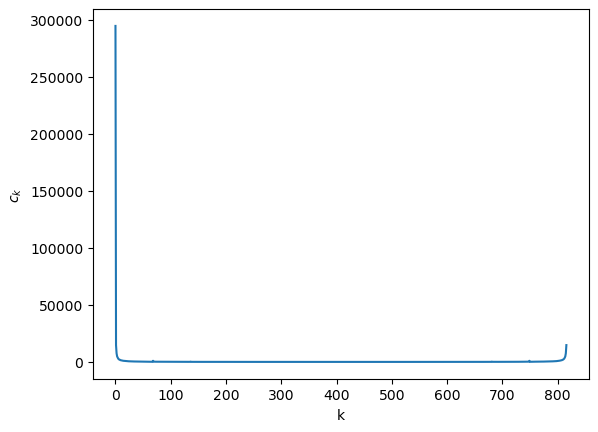

In [16]:
# plot the DFT

plt.plot(abs(c), '-')
plt.xlabel("k")
plt.ylabel(r"$c_k$")
plt.show()



You see we get a big spike at the first $c_k$, overwhelming all other values. If we look at the DFT,

$$
c_k =  \sum_{n=0}^{N-1}y_n\exp{\left(-i\frac{2\pi kn}{N}\right)}
$$

when k=0, we see 

$$
c_0=  \sum_{n=0}^{N-1}y_n
$$ 

and is just the sum of all of the data samples. If all the samples are positive, like here, $c_k$ will be very large. 



In [17]:
print(f"Number of measurements: {len(co2)}")
print(f"Sum of data: {np.sum(co2)}")

Number of measurements: 817
Sum of data: 294723.38


Since we typically don't care about the constant term we can subtract the mean from the dataset and recalculate the DFT.

Recalculate the DFT for data with the mean removed. 

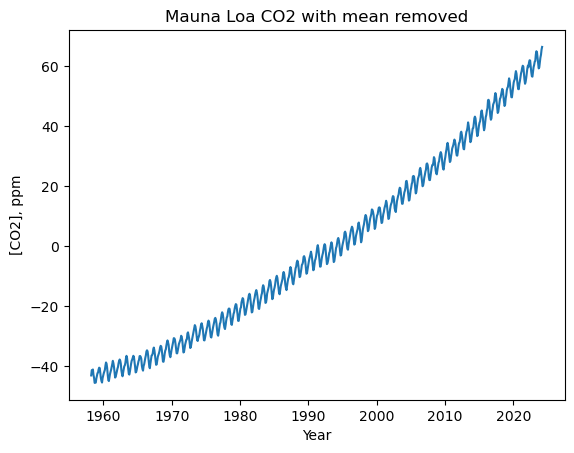

4.5645265345228836e-11


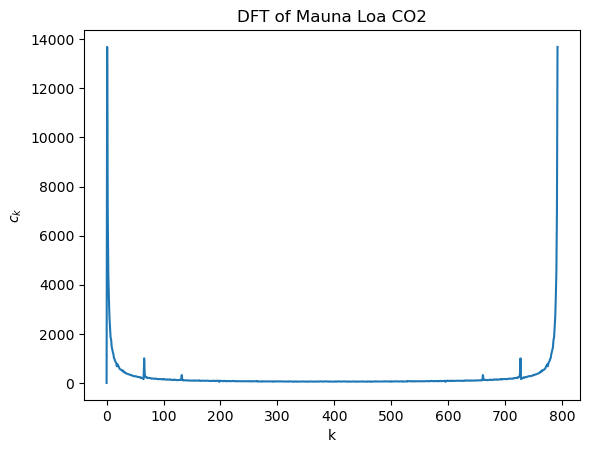

In [19]:
# Calculate DFT for Mauna Loa CO2 data with mean removed

import numpy as np
from cmath import exp, pi, phase
import matplotlib.pyplot as plt


# directory path to data file
path = "G:\\My Drive\\Classes\\Ph322\\Data files\\"
#file = "monthly_in_situ_co2_mlo.txt"

# load in the file "monthly_in_situ_co2_mlo.txt"
data = np.loadtxt(path+file)
#data = np.loadtxt(file)
# col 2 contains date in units of days
day = data[:,2]
# col 3 contains date in units of years
year = data[:,3]
# col 4 contains CO2 in units of ppb
co2 = data[:,4]

co2 = co2 - np.mean(co2)
#plot CO2 vs year
plt.plot(year, co2, '-')
plt.xlabel("Year")
plt.ylabel("[CO2], ppm")
plt.title("Mauna Loa CO2 with mean removed")
plt.show()

# calculate the DFT of the CO2 time series
c = dft(co2)

# plot the DFT
plt.plot(abs(c), '-')
plt.xlabel("k")
plt.ylabel(r"$c_k$")
plt.title("DFT of Mauna Loa CO2")
#plt.xlim(120,140)

print (abs(c[0]))

Now we can see interesting features in the DFT. 

First we see a very large spike, two actually, which we return to below. 

We also see some smaller spikes at higher values of k or higher frequencies. 

We also see smaller but continuous harmonics in between these spikes with an amplitude that decreases with $k$. 

Finally we see the spectrum is repeated in the second half of the plot, there is symmetry about the midpoint of the frequency interval. 

This is an expected result when working with real functions, or in this case real data. In fact, we only have to calculate $c_k$ for $k$ up to $N/2+1$. We will discuss why this result occurs below.

**Period of peak component**

Let's determine the periods of the peaks.

First we will use the numpy function ```np.argmax()``` to locate the array index of the max $c_k$ term. ```np.argmax()``` takes an array as an argument, and returns the index of the array where the maximum value occurs.

The function works like this:

In [27]:
import numpy as np

# output the index of the maximum ck value
imax = np.argmax(abs(c))
print(f"The max ck occurs at index {imax} and equals {abs(c[imax])}.")

The max ck occurs at index 1 and equals 11769.567647380027.


Since the coefficiencts are complex, I need to use the ```abs()``` function to look only for the real maximum value. Notice too how once I found the index imax where the maximum occurs, I put it back into the array to write out the maximum as well.

The maximum occurs at k=1. What is the period of this harmonic? To answer, let's again look at our equation for the DFT:


$$
c_k =  \sum_{n=0}^{N-1}y_n\exp{\left(-i\frac{2\pi kn}{N}\right)}
$$

The frequency of the harmonic is given by:

$
\omega = \frac{2\pi k}{N}
$

$n$ here acts as the x-coordinate so is not part of the frequency.

Since the period $T$ is related to $\omega$ as:

$$
T=\frac{2\pi}{\omega},
$$

we get: 

$
T=N/k.
$

The number of data points $N=817$, so at $k=1$, $T=817$. 

What are the units of $T$? 

Well the MLO data in the file are monthly, so the period is given in units of month. So $T=817$ months, which is about 68 years, the length of our data record. Interesting. 

What we found then, is the frequency component with the largest magnitude has a period equal to the length of our data record. Why?

Well, let's look at the data again. The main feature we see other than the seasonal cycle is the upward trend. The upward trend is antisymmetric, i.e. lower in the first half of the time series and higher in the second half.

What sinusoidal function could fit this? Well, just a sine wave with a period equal to the entire record.

Let's see this. 

The following code allows us to reconstruct our data series by summing the terms in the Fourier series. We can specify how many terms we wish to sum, by setting kmax. 

To plot up to the first term, set kmax=1. To plot all terms set kmax=N-1.

Let's first look at the first term, k=0.

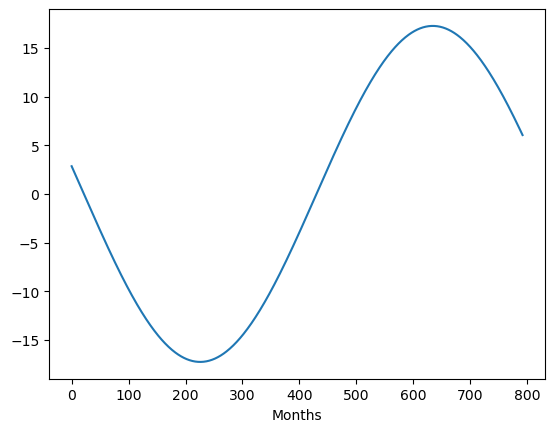

In [22]:
# code allows us to calculate, plot the sum of the first kmax terms of the Fourier series
# using DFT calculated above

import numpy as np
import matplotlib.pyplot as plt

T = 817 # period in units of months
N = len(c)
#kmax = N-1 # Add Fourier series terms up to kmax term
kmax=1
xvalues = np.arange(0,N,1)
yvalues = np.empty([N,N], complex)

sum = np.zeros([len(xvalues)], complex)
for k in range(0,kmax+1):
#for k in range(62,63):
    for x in range(N):
        sum[x] += (c[k]/N)*exp((2j*np.pi*k/T)*xvalues[x])
          
   

plt.plot(xvalues,sum)
plt.xlabel("Months")
plt.show()

We see this is just the constant offset we talked about. If we removed the mean from our data set, the constant term will be zero. 

Now add in the next term, kmax=1. Here is the term with a period of 817 months. You can see it is the first harmonic of the sine series. It is needed to approximate the strong trend in the record.

Now slowly increase kmax and replot. You see slowly we get back the original data series. Which of course isn't surprising, but is a good check that our code is working. 

If we add up all the terms by setting kmax=N-1, we get back the original time series.

So we see the first term represents the longterm trend of the time series. Let's calculate the periods of the other two peaks, i.e. the peaks in the lower half of the plot.

Zoom the DFT plot in around the second peak:

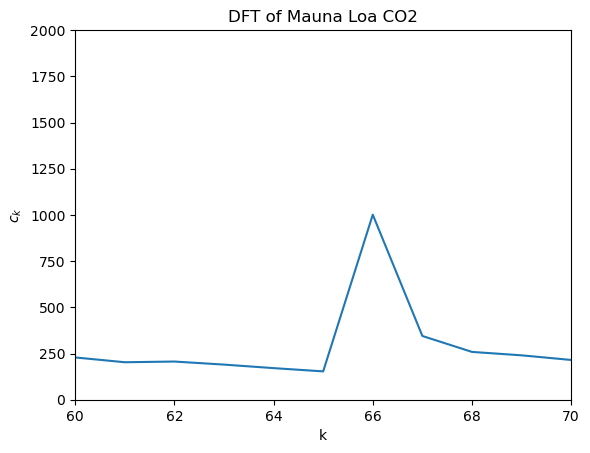

In [29]:
# plot the DFT
plt.plot(abs(c), '-')
plt.xlim(60,70)
plt.ylim(0,2000)
plt.xlabel("k")
plt.ylabel(r"$c_k$")
plt.title("DFT of Mauna Loa CO2")
plt.show()


The k index of the second highest peak occurs at k=66.  

Again we can find the period using $T=N/k$, the period is about 12 months. 

Well this makes sense. This is the component that corresponds to the seasonal cycle of CO2. As we see from this graph, it is a strong signal, so not surprising it stands out. 

Finally, let's look at the third peak:

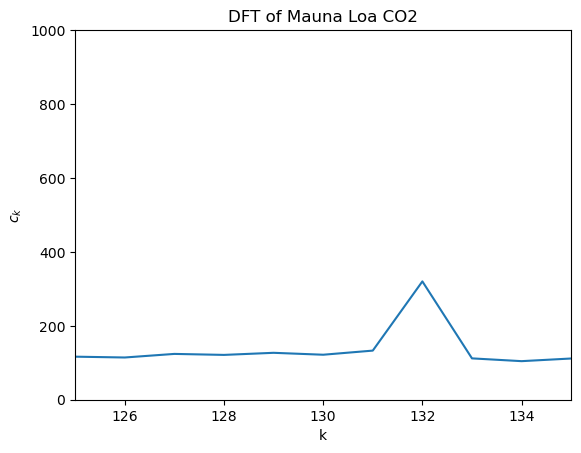

In [34]:
# plot the DFT
plt.plot(abs(c), '-')
plt.xlim(125,135)
plt.ylim(0,1000)
plt.xlabel("k")
plt.ylabel(r"$c_k$")
plt.title("DFT of Mauna Loa CO2")
plt.show()

This is occurs at k=132 or about 6 months. 

Is there a natural or human process that would repeat twice a year? 

Maybe. 

But more than likely this is a harmonic of the 12-month term. Because the seasonal cycle of CO2 is not exactly a sine or cosine wave, if we were to subtract a waveform with a 12-month term, we will get residuals that vary twice as fast. So this third peak arises likely because of this effect.

### Simplification of the DFT for real functions


If our function is real, for example sampled measurements like above, there's a trick we can use to reduce the number of computations we have to perform in calculating the DFT.


Suppose we have $N$ sampled points, i.e., we have $y_n$ for n=0, N-1. For this data set we compute the $c_k$ from the DFT. Suppose we look at a particular $c_k$ where $k$ is in the second half of the data set, i.e., $k$ is greater than $N/2$ and less than $N$. We write $k$ as $k=N-r$ where $1\le r< \frac{1}{2}N$.

Then using our DFT equation:

$$
c_k =  \sum_{n=0}^{N-1}y_n\exp{\left(-i\frac{2\pi kn}{N}\right)}
$$



$$
c_{N-r} =  \sum_{n=0}^{N-1}y_n\exp{\left(-i\frac{2\pi (N-r)n}{N}\right)}=\sum_{n=0}^{N-1}y_n\underbrace{\exp{(-i2\pi n)}}_{=1}\exp{\left(i\frac{2\pi rn}{N}\right)}
$$

where the first exponential equals 1 since $e^{-i\theta}=\cos{\theta}-i\sin{\theta}$ and $\theta$ is a multiple of $2\pi$. 

Therefore we can write this as:

$$
c_{N-r} = \sum_{n=0}^{N-1}y_n\exp{\left(i\frac{2\pi rn}{N}\right)}
$$


However this is just $c_r^*$, the complex conjugate of $c_r$,  that is $c_r$ with the sign of the imaginary part flipped. 

So

$$
c_{N-r}= c_r^*
$$

That means $c_{N-1}= c_1^*$, $c_{N-2}= c_2^*$, $\ldots$  

Therefore we only have to calculate half of the coefficients, the other half are just the complex conjugates of the first half so the real parts will be the same.

The general rule is:

We calculate $c_k$ for $0\le k \le \frac{1}{2}N$, e.g. if $N=8$, we calculate $c_k$ for $k=0,1,2,3,4$ or a total of $\frac{1}{2}N+1$ coefficients if $N$ is even, and $\frac{1}{2}(N+1)$ when $N$ is odd. Calculating only half the coefficients, reduces the computation time. However, if we reconstruct the data from $c_k$, we still need to consider the complex conjugates.